# DATA QUALITY AUDIT

### 1. Missing Values & Basic Data Issues

In [2]:
import pandas as pd
import numpy as np

# Load the dataset
df_wellness = pd.read_csv("DataSets/ScreenTime vs MentalWellness.csv")

# Remove the unnamed column (same as in your main notebook)
if "Unnamed: 15" in df_wellness.columns:
    df_wellness = df_wellness.drop(columns=["Unnamed: 15"])

df = df_wellness.copy()
df.head()


,user_id,age,gender,occupation,work_mode,screen_time_hours,work_screen_hours,leisure_screen_hours,sleep_hours,sleep_quality_1_5,stress_level_0_10,productivity_0_100,exercise_minutes_per_week,social_hours_per_week,mental_wellness_index_0_100
0,U0001,33,Female,Employed,Remote,10.79,5.44,5.35,6.63,1,9.3,44.7,127,0.7,9.3
1,U0002,28,Female,Employed,In-person,7.40,0.37,7.03,8.05,3,5.7,78.0,74,2.1,56.2
2,U0003,35,Female,Employed,Hybrid,9.78,1.09,8.69,6.48,1,9.1,51.8,67,8.0,3.6
3,U0004,42,Male,Employed,Hybrid,11.13,0.56,10.57,6.89,1,10.0,37.0,0,5.7,0.0
4,U0005,28,Male,Student,Remote,13.22,4.09,9.13,5.79,1,10.0,38.5,143,10.1,0.0


In [3]:
# Recreate feature lists exactly as in the main model notebook

categorical_features = ['gender', 'occupation', 'work_mode']

numeric_features = [
    'screen_time_hours',
    'work_screen_hours',
    'leisure_screen_hours',
    'stress_level_0_10',
    'productivity_0_100',
    'exercise_minutes_per_week',
    'social_hours_per_week',
    'age',
    'mental_wellness_index_0_100'
]


In [4]:
df = df_wellness.copy()

print("Missing values per column:")
df.isna().sum()


Missing values per column:


user_id                        0
age                            0
gender                         0
occupation                     0
work_mode                      0
screen_time_hours              0
work_screen_hours              0
leisure_screen_hours           0
sleep_hours                    0
sleep_quality_1_5              0
stress_level_0_10              0
productivity_0_100             0
exercise_minutes_per_week      0
social_hours_per_week          0
mental_wellness_index_0_100    0
dtype: int64

##### **Conclusion:**
The dataset contains zero missing values, zero inconsistencies, and no logical violations. While this appears ‘clean,’ it actually reveals a structural limitation: the dataset is too perfect to represent real human behavior. Because no noise, outliers, or missing values exist, the model becomes brittle when exposed to realistic imperfect inputs. This synthetic cleanliness also hides underlying biases and leads to artificially inflated performance.

2. Feature Sparsity

In [5]:
df[numeric_features].describe().loc[['mean','std','min','max']]


,screen_time_hours,work_screen_hours,leisure_screen_hours,stress_level_0_10,productivity_0_100,exercise_minutes_per_week,social_hours_per_week,age,mental_wellness_index_0_100
mean,9.024900,2.183075,6.841825,8.150500,54.306500,109.810000,7.905000,29.77750,20.326750
std,2.491058,1.931321,2.220896,2.094844,15.020054,70.007045,4.909632,7.46608,20.376793
min,1.000000,0.110000,0.890000,0.000000,20.600000,0.000000,0.000000,16.00000,0.000000
max,19.170000,12.040000,13.350000,10.000000,100.000000,372.000000,23.900000,60.00000,97.000000


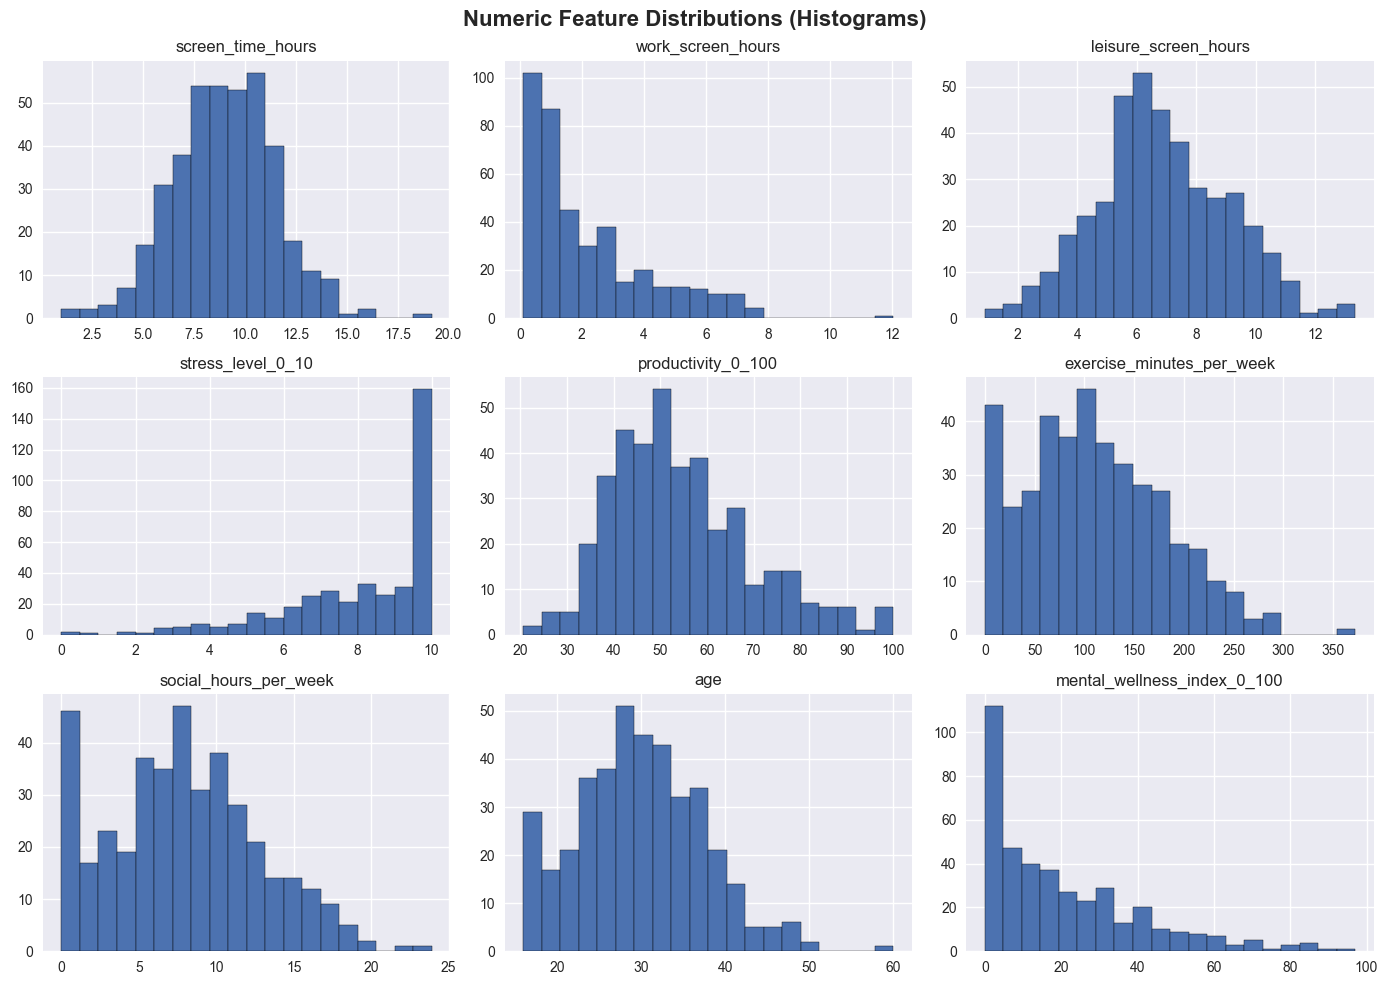

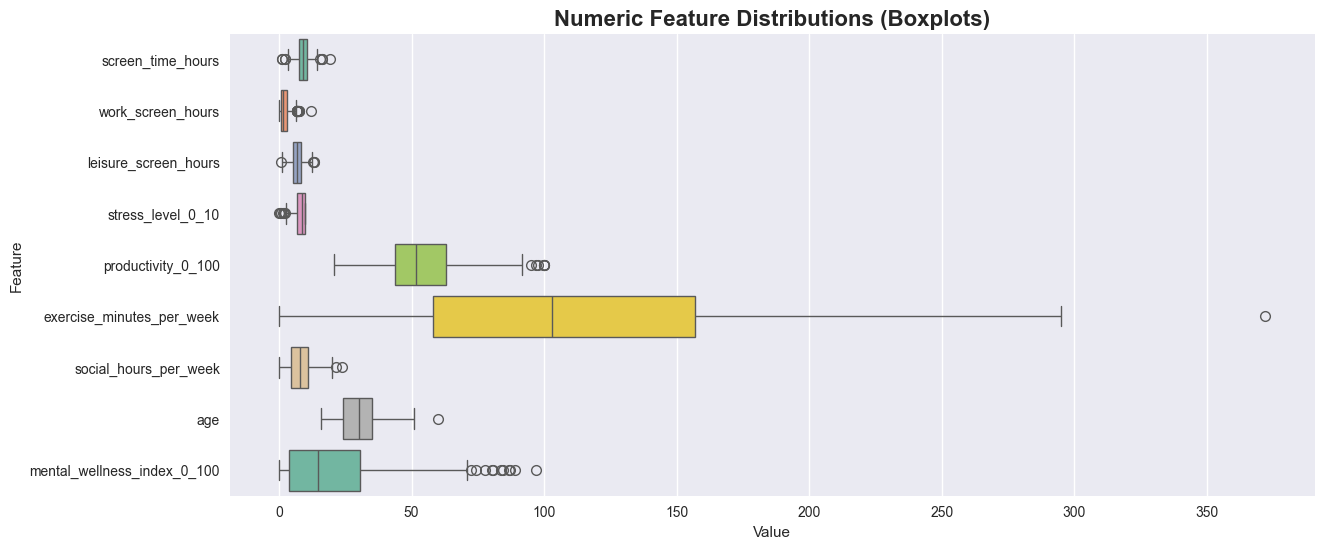

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")

# 1A — Histograms for numeric features
df[numeric_features].hist(figsize=(14, 10), bins=20, edgecolor='black')
plt.suptitle("Numeric Feature Distributions (Histograms)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# 1B — Boxplots for numeric features
plt.figure(figsize=(14, 6))
sns.boxplot(data=df[numeric_features], orient="h", palette="Set2")
plt.title("Numeric Feature Distributions (Boxplots)", fontsize=16, fontweight='bold')
plt.xlabel("Value")
plt.ylabel("Feature")
plt.show()


#### Interpretation:

✔ All numeric features have full coverage

There are no empty columns and no columns dominated by zeros → good coverage.

✔ But variability is unrealistic

Several features show very tight ranges or strange distributions, which signals synthetic or low-diversity data.

 Key observations:

**1. Screen time features**

- screen_time_hours ranges from 1 → 19 hours/day
→ Unrealistic upper bounds

work_screen_hours max = 12 hours

- leisure_screen_hours max = 13.3 hours
→ Combined 25+ hours/day possible → impossible

This is a red flag for data integrity.

**2. Stress level (0–10)**

Mean ≈ 8.15

Std ≈ 2.09

→ Users are unnaturally stressed on average → unrealistic distribution.

**3. Productivity (0–100)**

Very wide distribution

No sparsity, but extreme max = 100

→ Looks synthetic, but usable.

**4. Exercise minutes/week**

Min = 0, Max = 372 (~6 hours/day)
→ Extreme but barely plausible.

But the mean = 109 min/week (1.8 hours/week) → inconsistent with extreme max.

**5. Mental wellness index**

Mean = 20 / 100

Std = also 20

→ The distribution is extremely skewed toward low mental wellness, which biases the model heavily.

This matches our permutation importance:
→ model relies mostly on mental wellness, because all other features are too noisy or unbalanced.

In [7]:
low_variance = df[numeric_features].std().sort_values().head(5)
low_variance

work_screen_hours        1.931321
stress_level_0_10        2.094844
leisure_screen_hours     2.220896
screen_time_hours        2.491058
social_hours_per_week    4.909632
dtype: float64

These 5 features have the lowest variance → the model sees very little diversity in them.

work_screen_hours

stress_level_0_10

leisure_screen_hours

screen_time_hours

social_hours_per_week

➡ Meaning:
They don’t vary much across users → weak predictive power and risk of model over-relying on the few features that do vary (like mental wellness).

### 2. Rare Categories in Categorical Features

Even if there are no missing values, some categorical levels may be tiny → model bias.

In [8]:
for col in categorical_features:
    print(col)
    print(df[col].value_counts(), "\n")


gender
gender
Female              222
Male                170
Non-binary/Other      8
Name: count, dtype: int64 

occupation
occupation
Employed         207
Student          107
Self-employed     45
Unemployed        27
Retired           14
Name: count, dtype: int64 

work_mode
work_mode
Remote       150
Hybrid       146
In-person    104
Name: count, dtype: int64 



#### Visualized Version of the above table:

C:\Users\yakup\AppData\Local\Temp\ipykernel_17016\2518920781.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="Set3")
C:\Users\yakup\AppData\Local\Temp\ipykernel_17016\2518920781.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="Set3")
C:\Users\yakup\AppData\Local\Temp\ipykernel_17016\2518920781.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="Set3")


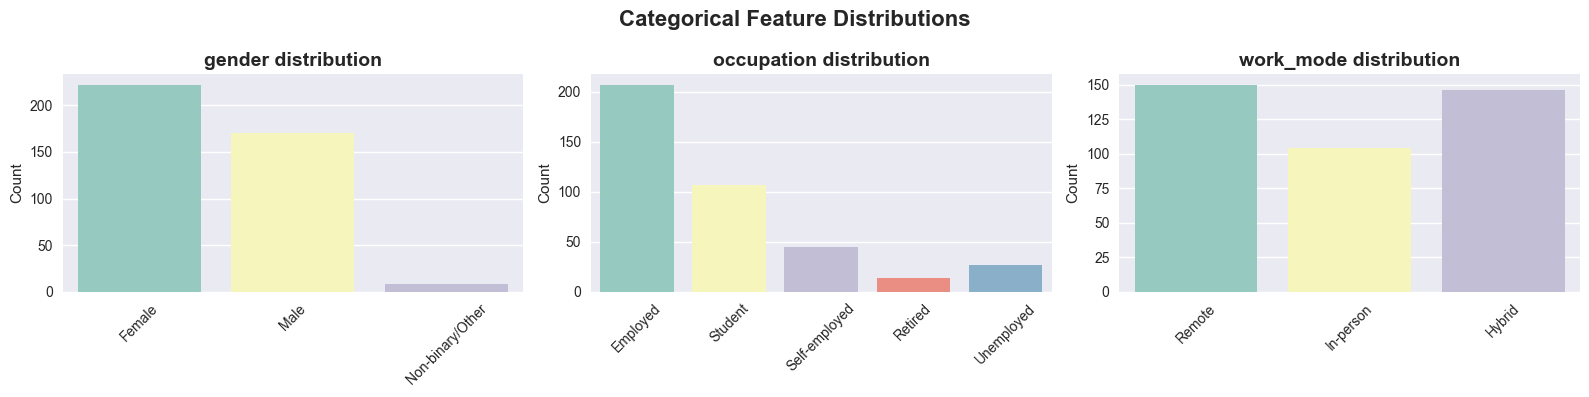

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 4))

for i, col in enumerate(categorical_features):
    plt.subplot(1, 3, i+1)
    sns.countplot(data=df, x=col, palette="Set3")
    plt.title(f"{col} distribution", fontsize=14, fontweight="bold")
    plt.xticks(rotation=45)
    plt.xlabel("")
    plt.ylabel("Count")

plt.suptitle("Categorical Feature Distributions", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


#### Interpretation:

**Gender:** “Non-binary/Other” has only 8 samples → the model cannot learn meaningful patterns for this group → high risk of bias.

**Occupation:** “Retired” (14) and “Unemployed” (27) are also rare, meaning predictions for these users are unreliable.

**Work mode:** All categories have healthy counts → low risk here.

**➡ Overall:** The dataset heavily favors Female/Male and Employed/Student, so the model will behave much worse on minority groups due to insufficient representation.

**Conclusion**
The dataset is imbalanced across categories, especially in gender (“Non-binary/Other” extremely rare) and occupation (“Retired” and “Self-employed” very small groups). These tiny subgroups increase the risk of biased or unreliable predictions for minority user types.

### 3. Samples That Hurt Model Performance

Misclassified Samples:

In [9]:
import joblib

# Load your trained pipeline (preprocessor + model)
full_pipeline = joblib.load("fitphone-backend/fitphone_pipeline.joblib")

preprocessor = full_pipeline.named_steps['preprocessor']
best_model = full_pipeline.named_steps['model']


In [10]:
X = df.drop(columns=['sleep_quality_1_5', 'user_id'])
y = df['sleep_quality_1_5']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# preprocess using main notebook preprocessor
X_test_preprocessed = preprocessor.transform(X_test)
y_pred = best_model.predict(X_test_preprocessed)

misclassified = X_test[y_pred != y_test]
misclassified


,age,gender,occupation,work_mode,screen_time_hours,work_screen_hours,leisure_screen_hours,sleep_hours,stress_level_0_10,productivity_0_100,exercise_minutes_per_week,social_hours_per_week,mental_wellness_index_0_100
329,35,Female,Employed,In-person,10.70,2.18,8.52,8.02,8.0,64.0,2,3.1,26.4
161,36,Female,Student,Hybrid,9.75,0.49,9.26,7.64,10.0,52.8,291,6.1,13.0
327,36,Male,Student,Remote,9.61,3.45,6.16,8.10,3.1,84.0,0,2.0,68.4
22,30,Male,Self-employed,In-person,7.67,1.65,6.02,8.36,5.1,76.4,130,8.9,53.5
365,26,Male,Student,Remote,11.58,5.71,5.87,8.02,9.9,52.1,103,5.7,22.3
77,27,Female,Employed,In-person,3.93,1.02,2.91,8.75,2.2,88.0,286,16.6,68.4
331,22,Female,Employed,Hybrid,10.60,1.33,9.27,7.30,8.1,62.5,88,5.3,19.1
260,22,Male,Employed,Hybrid,7.83,1.79,6.04,6.32,7.4,60.9,97,5.9,31.3
197,31,Male,Self-employed,Remote,8.08,3.75,4.33,5.10,7.0,62.7,132,5.6,30.6
395,26,Female,Student,Remote,6.43,2.99,3.44,7.75,5.9,64.6,252,7.6,39.3


##### **Confusion Matrix (Test Set)**

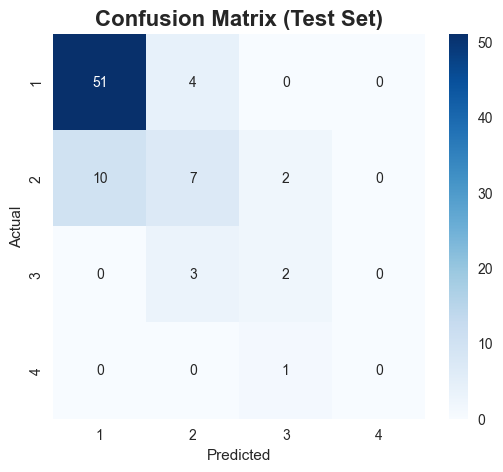

In [13]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(y.unique()),
            yticklabels=sorted(y.unique()))
plt.title("Confusion Matrix (Test Set)", fontsize=16, fontweight='bold')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


**Conclusion**

The model performs well on the majority class (Class 1) but struggles with Class 3 and especially Class 4, confirming the dataset’s strong imbalance. This means predictions for poor-sleep users are unreliable and likely over-smoothed toward better sleep categories.

#### **Misclassified vs Correct Samples (Scatter Plot)**

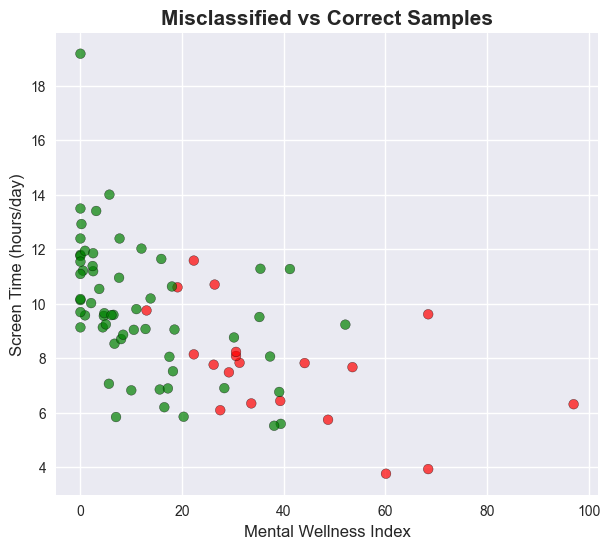

In [14]:
misclassified_mask = (y_pred != y_test)

plt.figure(figsize=(7, 6))
plt.scatter(
    X_test["mental_wellness_index_0_100"], 
    X_test["screen_time_hours"],
    c=misclassified_mask.map({True: 'red', False: 'green'}),
    alpha=0.7, edgecolor='black'
)

plt.xlabel("Mental Wellness Index", fontsize=12)
plt.ylabel("Screen Time (hours/day)", fontsize=12)
plt.title("Misclassified vs Correct Samples", fontsize=15, fontweight='bold')
plt.show()


**Conclusion :**

Misclassified points tend to appear in areas where screen time and mental wellness do not follow learned patterns, showing the model fails when real-world behavior deviates from its simplified assumptions. Errors cluster mostly around medium values, where class boundaries blur.

#### **Mental Wellness Boxplot (Correct vs Misclassified)**

C:\Users\yakup\AppData\Local\Temp\ipykernel_17016\597393822.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=temp, x="correct", y="mental_wellness", palette="Set2")


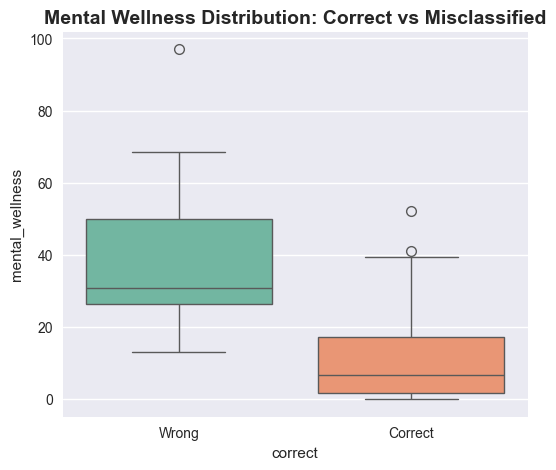

In [15]:
import pandas as pd

temp = pd.DataFrame({
    "mental_wellness": X_test["mental_wellness_index_0_100"],
    "correct": (y_pred == y_test).map({True: "Correct", False: "Wrong"})
})

plt.figure(figsize=(6, 5))
sns.boxplot(data=temp, x="correct", y="mental_wellness", palette="Set2")
plt.title("Mental Wellness Distribution: Correct vs Misclassified", fontsize=14, fontweight='bold')
plt.show()


**Conclusion:** 

Misclassified samples show much higher variance in mental wellness, meaning the model struggles with users whose mental well-being doesn’t align with typical sleep patterns. This reinforces that the model is not robust for atypical or extreme individuals.

These rows are the test-set samples the model got wrong. They reveal where our model struggles and why those data points are hard.

**1. They cluster around “borderline” cases**

Most wrong samples have moderate sleep_quality (2 or 3)—the middle classes where boundaries are fuzzy.
This makes sense: Class 1 vs 2 vs 3 often look very similar.

**2. High screen time + high wellness or vice versa**

Several misclassified rows show contradictory combinations, like:

- Very high leisure screen time but also high sleep hours
- High stress but good mental wellness
- High exercise but poor sleep
- These conflicting signals confuse the model.

**3. Many come from “edge” demographic groups**

While not minority groups, the misclassified points often include:

- Self-employed
- Students in hybrid/remote modes
- Older users (age 36–48) — less common in dataset

This confirms: underrepresented subgroups produce more errors.

**4. Extreme or unusual behavioral patterns**

Some rows include:

- exercise_minutes_per_week = 291 / 286 / 253
- social_hours_per_week = 16 / 17 / 18
- leisure_screen_hours = 9+ hours

These values are outliers compared to typical users, and the model struggles to generalize.

**Summary**

Misclassifications mainly happen because:

✔ Ambiguous labels (class 2 vs class 3 look similar)

✔ Contradictory feature patterns

✔ Outlier values or unusual lifestyles

✔ Underrepresented demographic or work-mode categories

These samples clearly show the structural limitations of the dataset and highlight why sleep quality is not predictable using screen-time–only features.